Notebook to generate more soruce files by sampling from the distribution in musource.txt

In [56]:
infile = 'musource.txt'

In [57]:
make_momentum_cut = True
pmin, pmax = 0.995, 1.005
target_momentum = 80 # mev

In [58]:
import pandas
# read_csv on whitespace is ~6x faster than read_fwf here, and read_fwf mis-infers
# the width of column 8 (event id), truncating e.g. 101 -> 1.
df = pandas.read_csv(infile, sep=r'\s+', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,2.63,-8.56,-958.0,2.495,-3.723,153.118,0,-13,1,0,0,1
1,0.66,-4.85,-958.0,-1.505,11.193,153.583,0,-13,2,0,0,1
2,39.49,-1.10,-958.0,-1.900,-11.203,153.323,0,-13,3,0,0,1
3,-1.39,-0.42,-958.0,2.649,14.564,156.013,0,-13,4,0,0,1
4,11.68,1.36,-958.0,0.254,12.559,152.015,0,-13,5,0,0,1


In [59]:
import numpy as np

In [60]:
names = {
    0:'x',
    1:'y',
    2:'z',
    3:'px',
    4:'py',
    5:'pz',
    'p':'p'
}

dfi = df.copy()
dfi['p'] = np.sqrt(dfi[3]**2 + dfi[4]**2 + dfi[5]**2)
input_p = dfi['p'].copy()
dfi.head()

,0,1,2,3,4,5,6,7,8,9,10,11,p
0,2.63,-8.56,-958.0,2.495,-3.723,153.118,0,-13,1,0,0,1,153.183575
1,0.66,-4.85,-958.0,-1.505,11.193,153.583,0,-13,2,0,0,1,153.997682
2,39.49,-1.10,-958.0,-1.900,-11.203,153.323,0,-13,3,0,0,1,153.743486
3,-1.39,-0.42,-958.0,2.649,14.564,156.013,0,-13,4,0,0,1,156.713699
4,11.68,1.36,-958.0,0.254,12.559,152.015,0,-13,5,0,0,1,152.533122


In [61]:
import hist

In [62]:
import matplotlib.pyplot as plt
import matplotlib

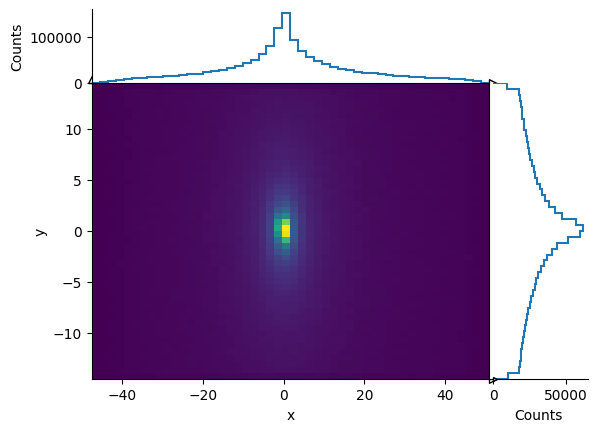

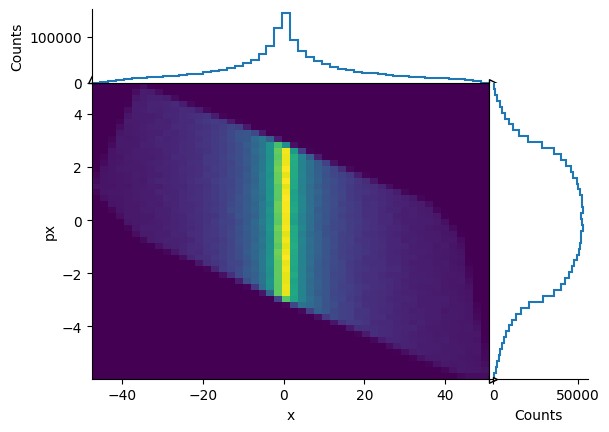

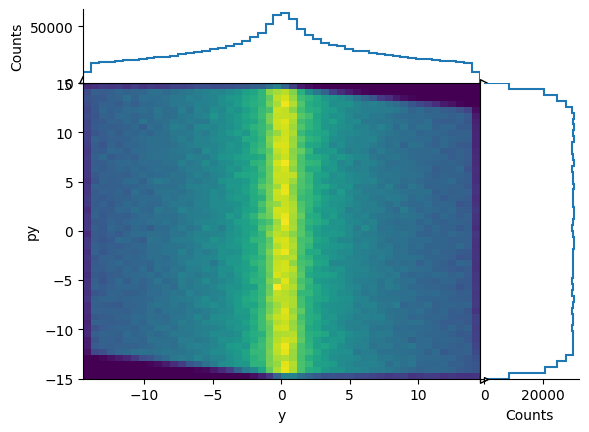

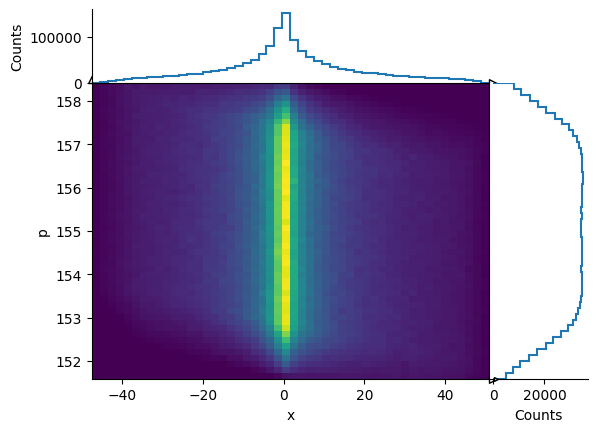

In [63]:
pairs = (
    (0,1),
    (0,3),
    (1,4),
    (0,'p')
)

for p1, p2 in pairs:
    hi = hist.Hist(
        hist.axis.Regular(50,dfi[p1].min(), dfi[p1].max(), label=names.get(p1,'unknown')),
        hist.axis.Regular(50,dfi[p2].min(), dfi[p2].max(), label=names.get(p2,'unknown')),
    )
    hi.fill(dfi[p1],dfi[p2])
    hi.plot2d_full(
        # norm = matplotlib.colors.LogNorm(vmin=1)
    )
    plt.show()
    # break

In [64]:
import matplotlib.pyplot as plt

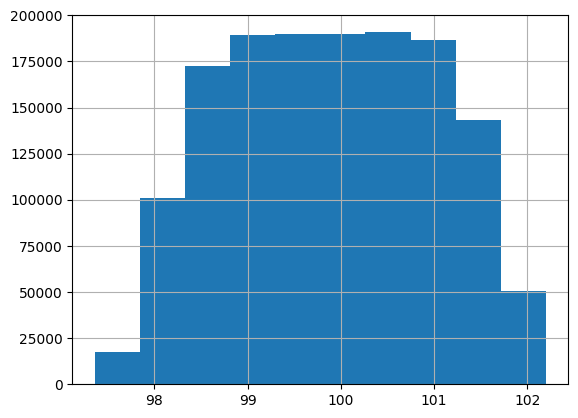

In [65]:
(df[5]*100/155.).hist() 
plt.show()

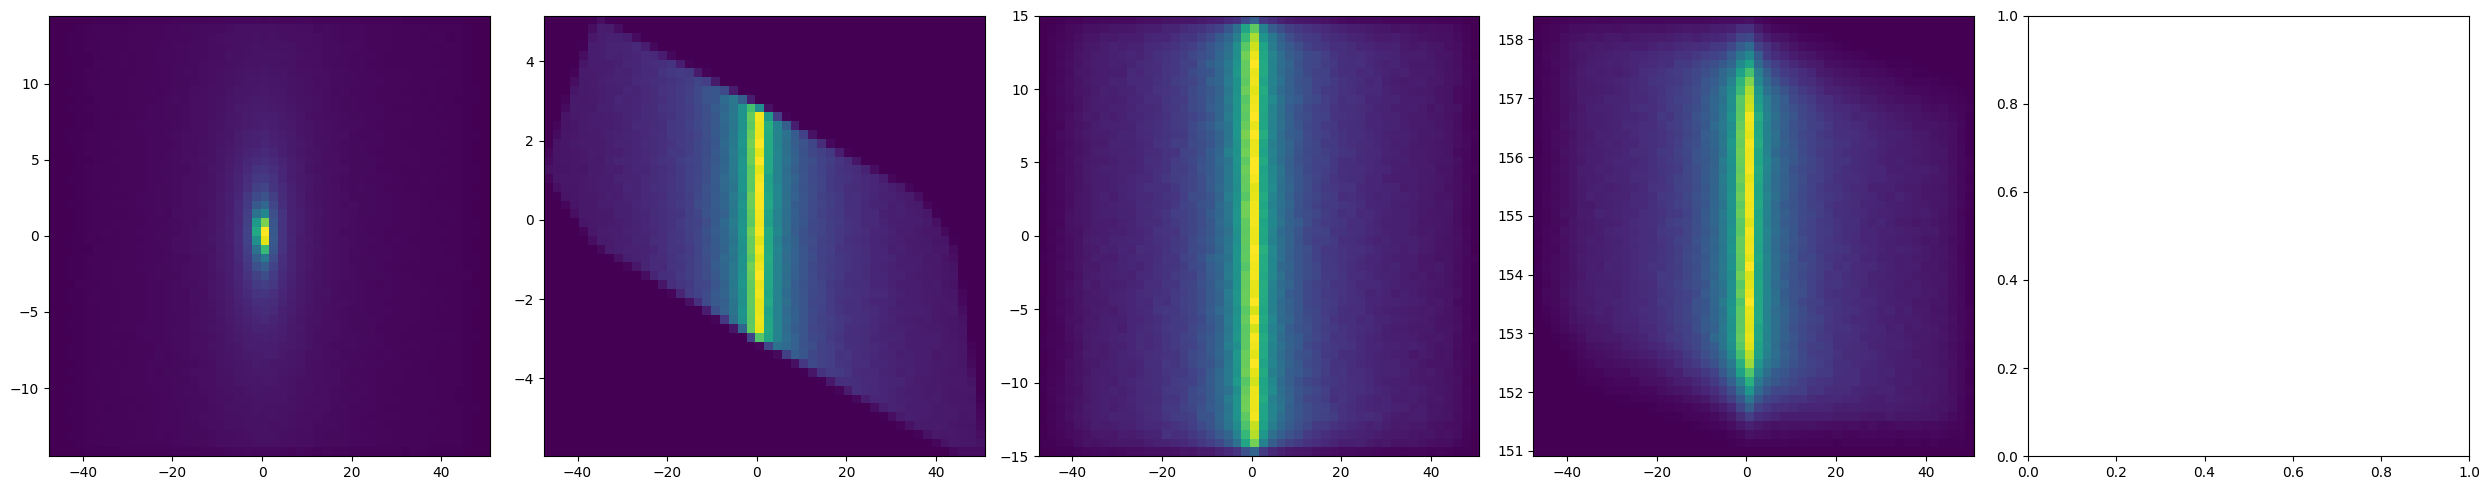

In [66]:
fig,ax = plt.subplots(1,5,figsize=(25,5))
ax[0].hist2d(df[0],df[1], bins=50)
ax[1].hist2d(df[0],df[3], bins=50)
ax[2].hist2d(df[0],df[4], bins=50)
ax[3].hist2d(df[0],df[5], bins=50)
plt.tight_layout()
plt.show()

In [67]:
# Columns to model (z is constant, so omit it)
cols = [0, 1, 3, 4, 5]

dfi = df[cols].drop_duplicates()
dfi.shape

(1431324, 5)

In [68]:
dfi.head()

,0,1,3,4,5
0,2.63,-8.56,2.495,-3.723,153.118
1,0.66,-4.85,-1.505,11.193,153.583
2,39.49,-1.10,-1.900,-11.203,153.323
3,-1.39,-0.42,2.649,14.564,156.013
4,11.68,1.36,0.254,12.559,152.015


## Sampling

The model is a local-covariance KDE: each source particle defines a neighbourhood of
its `k` nearest neighbours, and a new particle is drawn from the Gaussian with that
neighbourhood's mean and covariance.

Two changes make this tractable at `oversample * len(X)` output particles:

1. **Cache the local Gaussians.** Only `len(X)` distinct neighbourhoods exist, but the
   naive loop rebuilt one per *output* particle -- so every neighbourhood was queried,
   covaried and eigendecomposed ~`oversample` times over. We instead precompute the
   mean and the Cholesky factor for `n_anchors` randomly chosen particles once, and
   sampling reduces to a gather plus a 5x5 matvec. Everything is batched, so the tree
   query is multithreaded and the covariances/factorizations are single stacked calls.
2. **Standardize the coordinates.** The columns differ in rms by an order of magnitude,
   so an unweighted KD-tree query in raw units is driven almost entirely by `x` and
   `py`. Searching in units of each column's rms gives genuinely local neighbourhoods
   in all five dimensions.


In [69]:
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

# --------------------------------------------------------------------
# Sampler configuration
# --------------------------------------------------------------------
cfg = dict(
    cols           = [0, 1, 3, 4, 5],  # columns to model (z is constant, so omit it)
    k              = 64,               # nearest neighbours per local neighbourhood
    n_anchors      = 100_000,          # particles whose local Gaussian we cache and reuse
    oversample     = 2,               # N_new = oversample * len(X)
    # oversample     = 0.0020,               # N_new = oversample * len(X)
    regularization = 1e-8,             # covariance jitter, in standardized units
    chunk          = 2_000_000,        # samples drawn per vectorized batch
    seed           = 42,
)
cols = cfg['cols']

X = dfi.to_numpy(dtype=np.float64)

# --------------------------------------------------------------------
# Standardize before building the tree.
#
# The modelled columns live on very different scales (rms: x 17 mm, y 7 mm,
# px 2 MeV/c, py 8 MeV/c, pz 1.7 MeV/c), so a Euclidean KD-tree query in raw
# units is dominated by x and py and barely sees px and pz -- the "local"
# neighbourhood is only local in two of the five dimensions.  Dividing each
# column by its rms makes the search isotropic in the coordinates we care
# about; the local means/covariances are estimated in the same standardized
# space and mapped back at the end.
# --------------------------------------------------------------------
center = X.mean(axis=0)
scale  = X.std(axis=0)
Z = (X - center) / scale

tree = cKDTree(Z)

print(f'{X.shape=}')
print('center', np.round(center, 4))
print('scale ', np.round(scale, 4))

X.shape=(1431324, 5)
center [ 1.039500e+00  5.090000e-02 -1.428000e-01 -1.400000e-03  1.548334e+02]
scale  [17.141   7.0259  2.0236  8.2391  1.7016]


In [70]:
from tqdm import tqdm

In [71]:
%%time

# --------------------------------------------------------------------
# Cache one local Gaussian per anchor particle.
#
# The old loop did a tree query + a covariance + an eigendecomposition
# (rng.multivariate_normal) once per *output* particle, i.e. 20 * len(X)
# ~ 2.9e7 times, even though only len(X) distinct neighbourhoods exist -- so
# every neighbourhood was rebuilt ~20 times over.  Instead: draw n_anchors
# particles once, and for each store the local mean and the Cholesky factor of
# the local covariance.  Everything is batched, so the tree query runs
# multithreaded and the covariances/Choleskys are a single stacked LAPACK call.
# --------------------------------------------------------------------
rng = np.random.default_rng(cfg['seed'])
k = cfg['k']
d = X.shape[1]
diag = np.arange(d)

n_anchors = min(cfg['n_anchors'], len(Z))
anchor_idx = rng.choice(len(Z), size=n_anchors, replace=False)

# one batched, multithreaded query instead of N_new single-point queries
_, nn = tree.query(Z[anchor_idx], k=k, workers=-1)

neighborhood = Z[nn]                                    # (A, k, d)
anchor_mu = neighborhood.mean(axis=1)                   # (A, d)
c = neighborhood - anchor_mu[:, None, :]
anchor_cov = np.einsum('aki,akj->aij', c, c) / (k - 1)  # (A, d, d)
del neighborhood, c, nn

# Regularize, then factor. np.linalg.cholesky is batched over the anchor axis;
# it raises if *any* matrix is not positive definite, so back off with more
# jitter in that case (k >> d and duplicates are dropped, so this is rare).
jitter = cfg['regularization']
for attempt in range(8):
    trial = anchor_cov.copy()
    trial[:, diag, diag] += jitter
    try:
        anchor_L = np.linalg.cholesky(trial)
        break
    except np.linalg.LinAlgError:
        jitter *= 100
        print(f'local covariance not positive definite; raising jitter to {jitter:g}')
else:
    raise RuntimeError('local covariances are not positive definite')
del trial

print(f'cached {n_anchors:,} local Gaussians in '
      f'{(anchor_mu.nbytes + anchor_L.nbytes) / 1e6:.0f} MB (jitter={jitter:g})')

cached 100,000 local Gaussians in 24 MB (jitter=1e-08)
CPU times: user 36 s, sys: 1.37 s, total: 37.4 s
Wall time: 5.95 s


In [72]:
%%time

# --------------------------------------------------------------------
# Generate samples: pick a cached anchor, then draw from its local Gaussian.
# x = mu + L @ g  with g ~ N(0, I) is the same draw multivariate_normal makes,
# but the factorization is already done, so this is one gather + one d x d
# matvec per particle.  Chunked to keep peak memory bounded.
# --------------------------------------------------------------------
N_new = int(len(X) * cfg['oversample'])
samples = np.empty((N_new, d))

for lo in tqdm(range(0, N_new, cfg['chunk'])):
    hi = min(lo + cfg['chunk'], N_new)
    a = rng.integers(n_anchors, size=hi - lo)
    g = rng.standard_normal((hi - lo, d))
    samples[lo:hi] = anchor_mu[a] + np.einsum('nij,nj->ni', anchor_L[a], g)

samples *= scale          # back to physical units
samples += center

upsampled = pd.DataFrame(samples, columns=cols)

# Add z back
upsampled.insert(2, 2, -958.0)

100%|██████████| 2/2 [00:01<00:00,  1.10it/s]

CPU times: user 1.45 s, sys: 509 ms, total: 1.96 s
Wall time: 1.95 s


In [73]:
# --------------------------------------------------------------------
# Sanity check: do the upsampled marginals and correlations match the source?
# --------------------------------------------------------------------
q = [1, 5, 25, 50, 75, 95, 99]
print('col     mean(data)  mean(new)    rms(data)   rms(new)  rms ratio')
for j, col in enumerate(cols):
    print(f'{col:3d} {X[:, j].mean():12.4f} {samples[:, j].mean():10.4f} '
          f'{X[:, j].std():12.4f} {samples[:, j].std():10.4f} '
          f'{samples[:, j].std() / X[:, j].std():10.4f}')

print(f'\npercentiles {q}')
for j, col in enumerate(cols):
    print(f'{col:3d} data', np.round(np.percentile(X[:, j], q), 3))
    print(f'{col:3d} new ', np.round(np.percentile(samples[:, j], q), 3))

print('\nmax |corr(new) - corr(data)| =',
      np.abs(np.corrcoef(samples.T) - np.corrcoef(X.T)).max().round(5))

# fig, ax = plt.subplots(2, 5, figsize=(25, 9))
# pairs = [(0, 1), (0, 2), (1, 3), (0, 4), (2, 4)]
# for c, (i, j) in enumerate(pairs):
#     rng_i = np.percentile(X[:, i], [0.1, 99.9])
#     rng_j = np.percentile(X[:, j], [0.1, 99.9])
#     ax[0, c].hist2d(X[:, i], X[:, j], bins=80, range=[rng_i, rng_j])
#     ax[1, c].hist2d(samples[:, i], samples[:, j], bins=80, range=[rng_i, rng_j])
#     ax[0, c].set_title(f'data: {cols[i]} vs {cols[j]}')
#     ax[1, c].set_title(f'upsampled: {cols[i]} vs {cols[j]}')
# plt.tight_layout()
# plt.show()

col     mean(data)  mean(new)    rms(data)   rms(new)  rms ratio
  0       1.0395     1.0592      17.1410    16.9422     0.9884
  1       0.0509    -0.0099       7.0259     6.9755     0.9928
  3      -0.1428    -0.1428       2.0236     2.0117     0.9941
  4      -0.0014     0.0444       8.2391     8.2005     0.9953
  5     154.8334   154.8355       1.7016     1.6944     0.9958

percentiles [1, 5, 25, 50, 75, 95, 99]
  0 data [-39.02 -29.38  -7.69   0.36   9.41  33.36  43.9 ]
  0 new  [-38.541 -29.073  -7.408   0.346   9.154  33.196  43.522]
  1 data [-13.77 -11.96  -4.96   0.11   5.04  11.99  13.77]
  1 new  [-13.55  -11.92   -5.002   0.077   4.928  11.873  13.52 ]
  3 data [-4.763 -3.426 -1.665 -0.106  1.426  2.995  4.021]
  3 new  [-4.74  -3.425 -1.659 -0.099  1.416  2.961  3.979]
  4 data [-1.4226e+01 -1.2822e+01 -7.1070e+00  7.0000e-03  7.1030e+00  1.2806e+01
  1.4216e+01]
  4 new  [-14.056 -12.667  -7.089   0.083   7.157  12.677  14.064]
  5 data [151.614 152.14  153.424 154.837 1

In [74]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,2.63,-8.56,-958.0,2.495,-3.723,153.118,0,-13,1,0,0,1
1,0.66,-4.85,-958.0,-1.505,11.193,153.583,0,-13,2,0,0,1
2,39.49,-1.10,-958.0,-1.900,-11.203,153.323,0,-13,3,0,0,1
3,-1.39,-0.42,-958.0,2.649,14.564,156.013,0,-13,4,0,0,1
4,11.68,1.36,-958.0,0.254,12.559,152.015,0,-13,5,0,0,1


In [75]:
upsampled[6] = 0
upsampled[7] = -13
upsampled[8] = upsampled.index 
upsampled[9] = 0
upsampled[10] = 0
upsampled[11] = 1

In [76]:
upsampled

,0,1,2,3,4,5,6,7,8,9,10,11
0,-10.499777,-4.070256,-958.0,-1.243752,1.794302,158.224415,0,-13,0,0,0,1
1,13.782380,-6.799356,-958.0,-1.283412,-0.278839,152.546384,0,-13,1,0,0,1
2,1.251264,-6.035262,-958.0,-0.115259,9.757077,155.493516,0,-13,2,0,0,1
3,-13.879450,-12.084175,-958.0,3.119749,4.610131,155.186793,0,-13,3,0,0,1
4,-3.350700,0.551401,-958.0,0.185010,6.756589,154.352992,0,-13,4,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2862643,8.429681,8.258614,-958.0,1.904922,3.302402,156.370790,0,-13,2862643,0,0,1
2862644,8.159380,9.078129,-958.0,0.311621,-9.133763,156.056424,0,-13,2862644,0,0,1
2862645,-23.700229,6.350184,-958.0,2.629911,-8.587606,153.602117,0,-13,2862645,0,0,1
2862646,-32.900803,-0.204321,-958.0,-0.600639,-1.877679,157.422487,0,-13,2862646,0,0,1


In [77]:
this_momentum = np.sqrt(upsampled[3]**2  + upsampled[4]**2 +upsampled[5]**2 ).mean()
print(f'{this_momentum/target_momentum=}')

for i in 3,4,5:
    upsampled[i] = upsampled[i] * target_momentum / this_momentum

this_momentum/target_momentum=np.float64(1.9383217195795317)


In [78]:
print(upsampled.shape)

(2862648, 12)


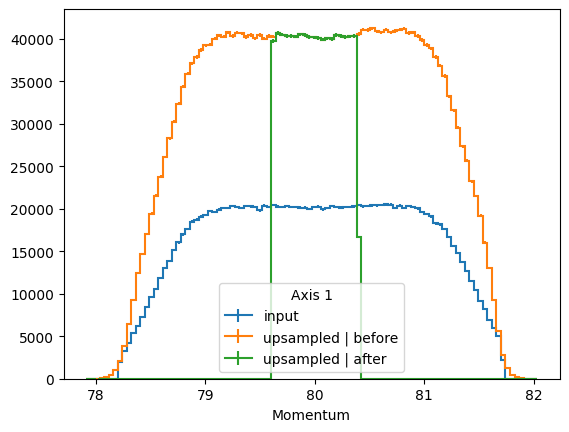

,0,1,2,3,4,5,6,7,8,9,10,11,p
0,1.251264,-6.035262,-958.0,-0.059463,5.033776,80.220695,0,-13,2,0,0,1,80.378494
1,-13.879450,-12.084175,-958.0,1.609511,2.378414,80.062454,0,-13,3,0,0,1,80.113943
2,-3.350700,0.551401,-958.0,0.095449,3.485794,79.632287,0,-13,4,0,0,1,79.708601
3,-27.489938,-6.527536,-958.0,1.233066,-0.212721,79.782166,0,-13,7,0,0,1,79.791978
4,14.066125,9.081532,-958.0,-0.107806,5.282620,79.854240,0,-13,12,0,0,1,80.028853


In [79]:
if make_momentum_cut: 
    upsampled['p'] = np.sqrt( upsampled[3]**2 + upsampled[4]**2 + upsampled[5]**2 )

    hi = hist.Hist(
        hist.axis.Regular(100,upsampled['p'].min(), upsampled['p'].max(),label='Momentum'),
        hist.axis.StrCategory(['input','upsampled | before', 'upsampled | after'])
    )
    hi.fill(input_p*(target_momentum / this_momentum), 'input')
    hi.fill(upsampled['p'], 'upsampled | before')

    upsampled = upsampled.loc[(upsampled['p'] >= pmin*target_momentum)&(upsampled['p'] <= pmax*target_momentum)]#.drop(columns=['p'])
    upsampled.reset_index(inplace=True, drop=True)
    hi.fill(upsampled['p'], 'upsampled | after')
    # upsampled = upsampled
    # upsampled
    hi.plot()
    plt.show()
upsampled.head()

In [80]:
print(upsampled.shape)

(781682, 13)


In [81]:
upsampled = upsampled.drop(columns='p')

In [82]:
for name,pid in {"mu":-13, "e":-11}.items():
    print(name,pid)
    upsampled[7] = pid
    outfile = f'./{name}source_upsampled_pcut_{target_momentum}.txt'
    upsampled.to_csv(outfile, sep=' ', header=False, index=False)


mu -13
e -11
